In [1]:
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import hist, processor
from coffea.hist import plot
from coffea.util import load
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

/work/mmarcheg/miniconda3/envs/btv/lib/python3.9/site-packages/coffea/util.py:154: FutureWarning: In coffea version v2023.3.0 (target date: 31 Mar 2023), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


In [2]:
#filename = "/pnfs/psi.ch/cms/trivcat/store/user/mmarcheg/BTVNanoCommissioning/store/user/mmarcheg/PFNano/BTagMu/Run2016B-ver2_HIPM_UL2016_MiniAODv2-v1_v01/220311_144252/0000/nano_data2016_518.root"
filename = "/pnfs/psi.ch/cms/trivcat/store/user/mmarcheg/BTVNanoCommissioning/store/user/mmarcheg/PFNano/BTagMu/Run2018D-UL2018_MiniAODv2-v1_PFNanoAOD/210525_134157/0000/nano_data2018_48.root"
events = NanoEventsFactory.from_root(filename, schemaclass=NanoAODSchema).events()
print("nEvents=", len(events))

/work/mmarcheg/miniconda3/envs/btv/lib/python3.9/site-packages/coffea/nanoevents/mapping/uproot.py:86: UserWarning: Found duplicate branch FatJet_btagDDBvLV2 in <TTree 'Events' (1602 branches) at 0x7f8fcc6f0ca0>, taking first instance
  warnings.warn(
/work/mmarcheg/miniconda3/envs/btv/lib/python3.9/site-packages/coffea/nanoevents/mapping/uproot.py:86: UserWarning: Found duplicate branch FatJet_btagDDCvBV2 in <TTree 'Events' (1602 branches) at 0x7f8fcc6f0ca0>, taking first instance
  warnings.warn(
/work/mmarcheg/miniconda3/envs/btv/lib/python3.9/site-packages/coffea/nanoevents/mapping/uproot.py:86: UserWarning: Found duplicate branch FatJet_btagDDCvLV2 in <TTree 'Events' (1602 branches) at 0x7f8fcc6f0ca0>, taking first instance
  warnings.warn(


nEvents= 71673


In [3]:
events = events[ak.count(events.FatJet.pt, axis=1) >=1]
events.FatJet

<FatJetArray [[FatJet, FatJet], ... [FatJet]] type='39236 * var * fatJet'>

In [4]:
ak.local_index(events.FatJet.pt)

<Array [[0, 1], [0], [0, ... 1], [0, 1], [0]] type='39236 * var * int64'>

In [5]:
pos = ak.local_index(events.FatJet.pt)
events["FatJet"] = ak.with_field(events.FatJet, pos, "pos")
events.FatJet.pos

<Array [[0, 1], [0], [0, ... 1], [0, 1], [0]] type='39236 * var * int64'>

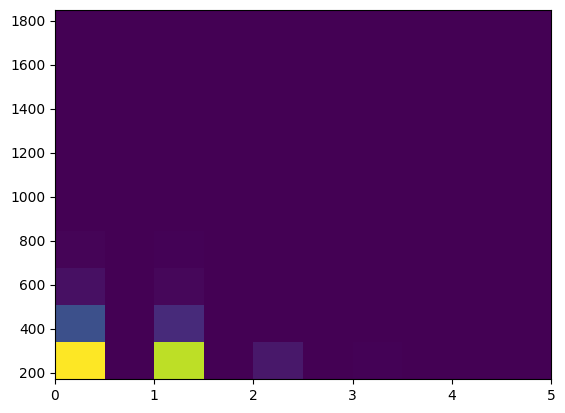

In [7]:
pos = ak.flatten(events.FatJet.pos)
pt = ak.flatten(events.FatJet.pt)
plt.hist2d(pos, pt);

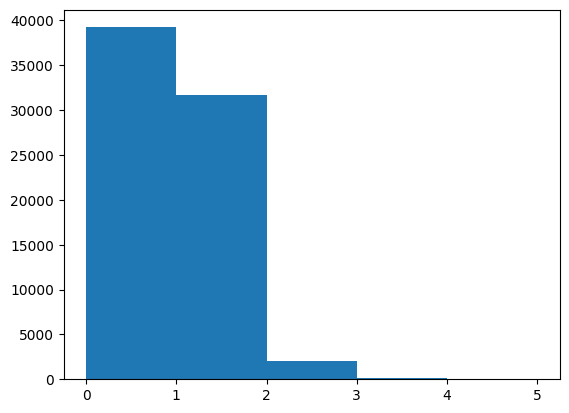

In [12]:
plt.hist(pos, range=(0,5), bins=5);